plotting ODES

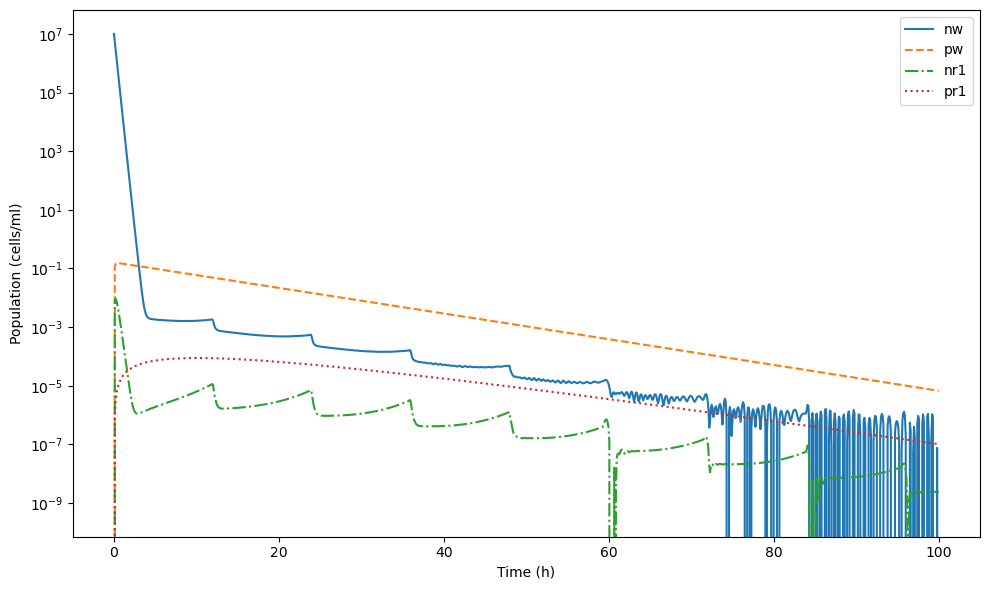

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

micWt = 1
micR1 = 4
gMax = 1.0
gMin = -6.5
hillKappa = 1
capacity = 5e9
aMax = 0.0001
bRate = 0.1
muWt = 1.5e-8
muP = 1.5e-4
decayRate = np.log(2) / 2.5
doseInterval = 12
aPeak = 25

immune = {
    'q': 3e-4,
    'emax': 1e6,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8
}

def drug(t):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growth(a, mic):
    return gMax - (gMax - gMin) * (a**hillKappa / (a**hillKappa + mic**hillKappa))

def system(t, y):
    nw, pw, nr1, pr1, e = y
    a = drug(t)
    total = nw + pw + nr1 + pr1
    aRate = aMax * total / capacity
    gNw = growth(a, micWt)
    gNr1 = growth(a, micR1)
    dNw = gNw * nw - aRate * nw + bRate * pw - muWt * nw - immune['jN'] * nw * e
    dPw = aRate * nw - bRate * pw - muP * pw - immune['jP'] * pw * e
    dNr1 = gNr1 * nr1 - aRate * nr1 + bRate * pr1 + muWt * nw - immune['jN'] * nr1 * e
    dPr1 = aRate * nr1 - bRate * pr1 + muP * pw - immune['jP'] * pr1 * e
    dE = immune['q'] * (immune['emax'] - e) - immune['l'] * e
    return [dNw, dPw, dNr1, dPr1, dE]

y0 = [1e7, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='nw', linestyle='-')
plt.plot(sol.t, sol.y[1], label='pw', linestyle='--')
plt.plot(sol.t, sol.y[2], label='nr1', linestyle='-.')
plt.plot(sol.t, sol.y[3], label='pr1', linestyle=':')
plt.yscale('log')
plt.xlabel('Time (h)')
plt.ylabel('Population (cells/ml)')
plt.legend()
plt.tight_layout()
plt.show()


4b (but only with NR1 step)

In [101]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': 0.0001,
    'b': 0.1,
    'm': 1.5e-8,
    'tau': 2,
    'h': 5,
    'muP': 1.5e-4,
    'immune': True,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2) / 2.5
}

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

4b but implemented all NR1, NR2, NR3 steps

/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_94253/1607774843.py:36: RuntimeWarning: overflow encountered in exp
  return m * g + tau * m * np.exp(-h * g)


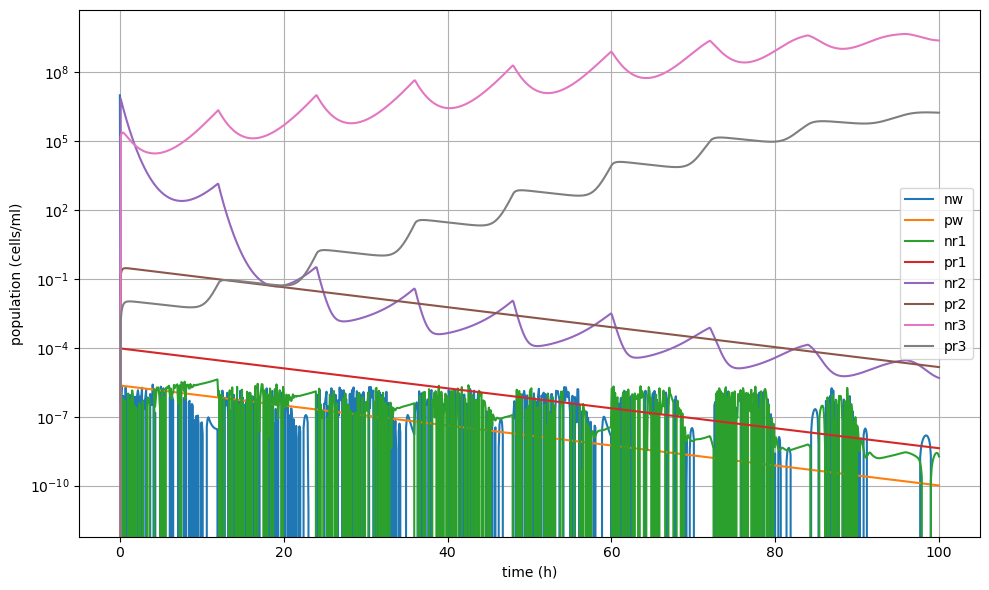

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': 0.0001,
    'b': 0.1,
    'm': 1.5e-8,
    'tau': 2,
    'h': 5,
    'muP': 1.5e-4,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2) / 2.5
}

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<>:117: SyntaxWarning: invalid escape sequence '\m'
<>:117: SyntaxWarning: invalid escape sequence '\m'
<>:117: SyntaxWarning: invalid escape sequence '\m'
<>:117: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2922828133.py:117: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2922828133.py:117: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2922828133.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


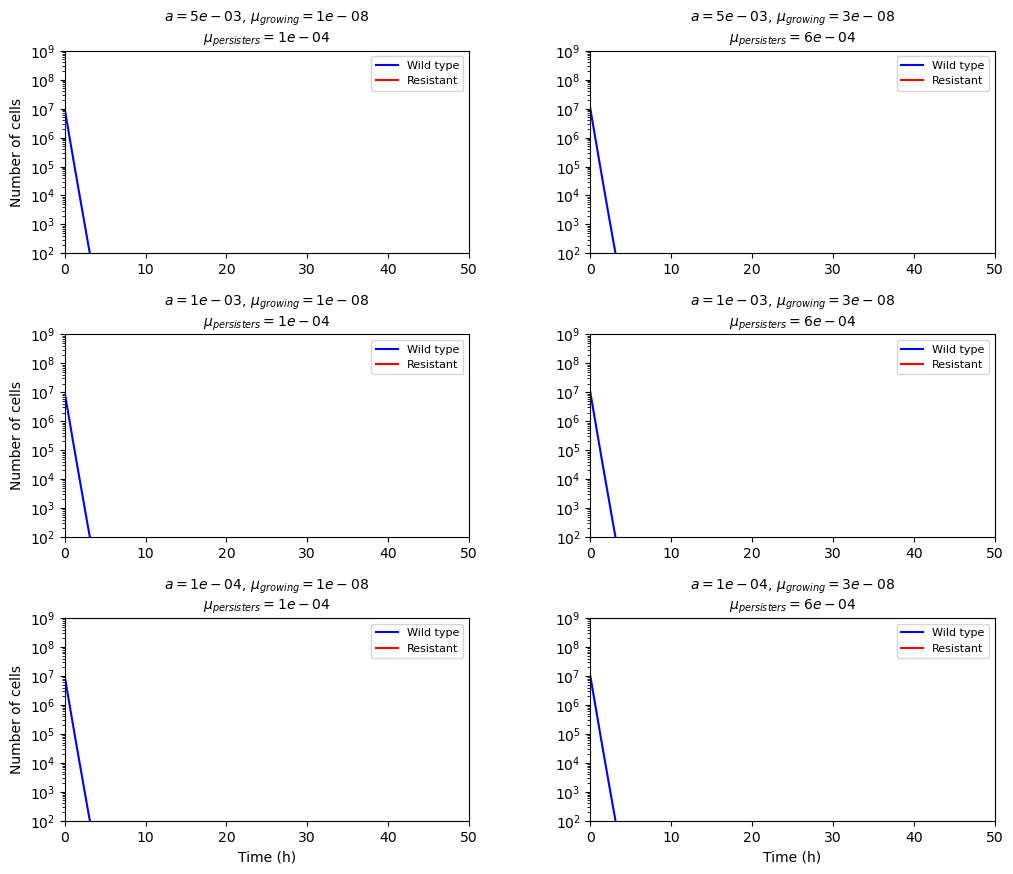

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ------------------------------
# Core Model Functions
# ------------------------------

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g) if g > 0 else 0

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax, gMin = p['gMax'], p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aSwitch = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aSwitch * nw + b * pw - muW * nw - jN * nw * e
    dPw = aSwitch * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aSwitch * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aSwitch * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aSwitch * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aSwitch * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aSwitch * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aSwitch * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

# ------------------------------
# Simulation Grid Setup
# ------------------------------

a_vals = [5e-3, 1e-3, 1e-4]
mutation_sets = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]

t_span = (0, 50)
t_eval = np.linspace(*t_span, 1000)

# Seed with small number of R1 cells
y0_seeded = [1e7, 0, 10, 0, 0, 0, 0, 0, 0]

results = {}
for i, a_val in enumerate(a_vals):
    for j, (mu_g, mu_p) in enumerate(mutation_sets):
        params = {
            'mic': [1, 4, 20, 50],
            'gMax': 1.0,
            'gMin': -4,
            'kappa': 1,
            'c': 5e9,
            'aMax': a_val,
            'b': 0.1,
            'm': mu_g,
            'tau': 2,
            'h': 5,
            'muP': mu_p,
            'immune': True,
            'mutation': True,
            'emax': 1e6,
            'q': 3e-4,
            'l': 1e-3,
            'jN': 5e-6,
            'jP': 5e-8,
            'aPeak': 25,
            'doseInterval': 12,
            'decayRate': np.log(2) / 2.5
        }
        sol = solve_ivp(system, t_span, y0_seeded, args=(params,), t_eval=t_eval)
        results[(i, j)] = (sol.t, sol.y)

# ------------------------------
# Plotting the Grid
# ------------------------------

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

for (i, j), (t, y) in results.items():
    ax = fig.add_subplot(gs[i, j])
    ax.plot(t, y[0], label='Wild type', color='blue')
    ax.plot(t, y[2]+y[4]+y[6], label='Resistant', color='red')
    ax.set_yscale('log')
    ax.set_ylim(1e2, 1e9)
    ax.set_xlim(0, t_span[1])
    if i == 2:
        ax.set_xlabel('Time (h)')
    if j == 0:
        ax.set_ylabel('Number of cells')
    ax.legend(fontsize=8)
    a_str = f'{a_vals[i]:.0e}'
    mu_g_str = f'{mutation_sets[j][0]:.0e}'
    mu_p_str = f'{mutation_sets[j][1]:.0e}'
    ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)

plt.tight_layout()
plt.show()


<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1351701067.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1351701067.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1351701067.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


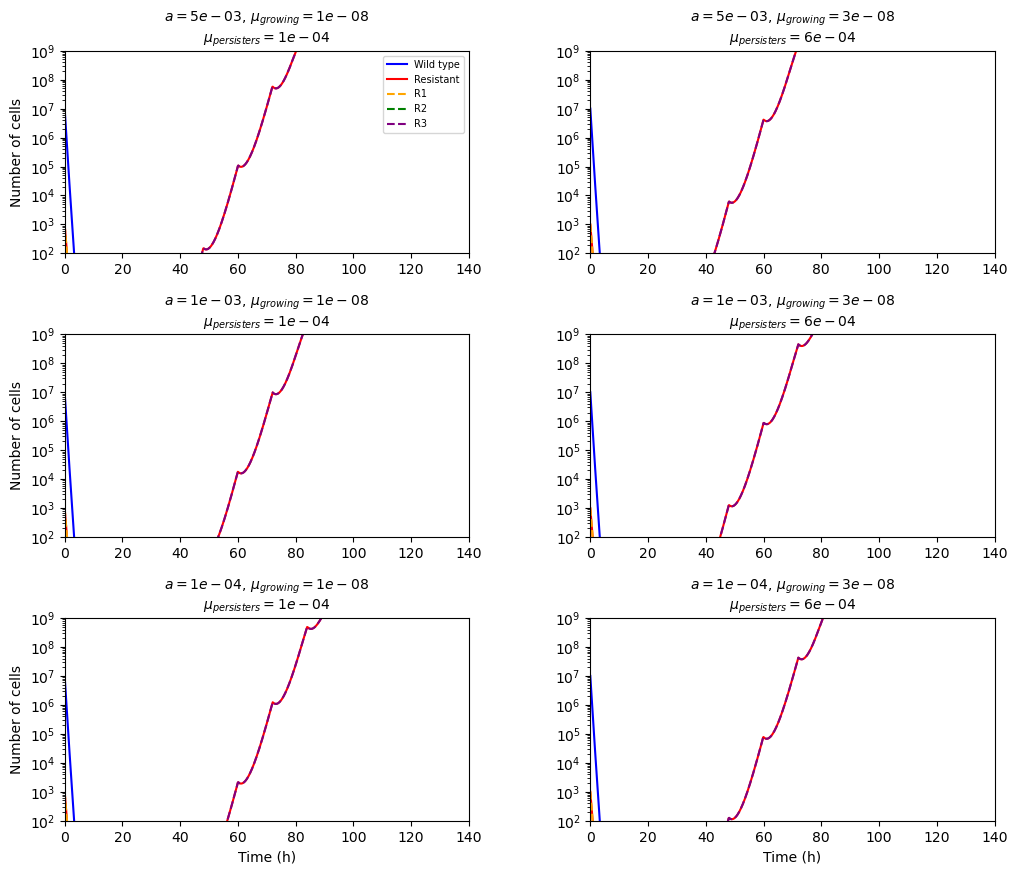

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Core Model Functions

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g) if g > 0 else 0

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax, gMin = p['gMax'], p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aSwitch = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aSwitch * nw + b * pw - muW * nw - jN * nw * e
    dPw = aSwitch * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aSwitch * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aSwitch * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aSwitch * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aSwitch * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aSwitch * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aSwitch * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

# Parameter grid setup

a_vals = [5e-3, 1e-3, 1e-4]
mutation_sets = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]

t_span = (0, 140)
t_eval = np.linspace(*t_span, 1000)
y0_seeded = [1e7, 0, 1000, 0, 0, 0, 0, 0, 0]

results = {}
for i, a_val in enumerate(a_vals):
    for j, (mu_g, mu_p) in enumerate(mutation_sets):
        params = {
            'mic': [1, 4, 20, 50],
            'gMax': 1.0,
            'gMin': -4,
            'kappa': 1,
            'c': 5e9,
            'aMax': a_val,
            'b': 0.1,
            'm': mu_g,
            'tau': 2,
            'h': 5,
            'muP': mu_p,
            'immune': True,
            'mutation': True,
            'emax': 1e6,
            'q': 3e-4,
            'l': 1e-3,
            'jN': 5e-6,
            'jP': 5e-8,
            'aPeak': 15,  # LOWERED from 25
            'doseInterval': 12,
            'decayRate': np.log(2) / 2.5
        }
        sol = solve_ivp(system, t_span, y0_seeded, args=(params,), t_eval=t_eval)
        results[(i, j)] = (sol.t, sol.y)

# Plotting

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

for (i, j), (t, y) in results.items():
    ax = fig.add_subplot(gs[i, j])
    ax.plot(t, y[0], label='Wild type', color='blue')
    ax.plot(t, y[2]+y[4]+y[6], label='Resistant', color='red')
    ax.plot(t, y[2], '--', color='orange', label='R1' if (i==0 and j==0) else "")
    ax.plot(t, y[4], '--', color='green', label='R2' if (i==0 and j==0) else "")
    ax.plot(t, y[6], '--', color='purple', label='R3' if (i==0 and j==0) else "")
    ax.set_yscale('log')
    ax.set_ylim(1e2, 1e9)
    ax.set_xlim(0, t_span[1])
    if i == 2:
        ax.set_xlabel('Time (h)')
    if j == 0:
        ax.set_ylabel('Number of cells')
    if i == 0 and j == 0:
        ax.legend(fontsize=7)
    a_str = f'{a_vals[i]:.0e}'
    mu_g_str = f'{mutation_sets[j][0]:.0e}'
    mu_p_str = f'{mutation_sets[j][1]:.0e}'
    ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)

plt.tight_layout()
plt.show()


<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2861937783.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2861937783.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2861937783.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


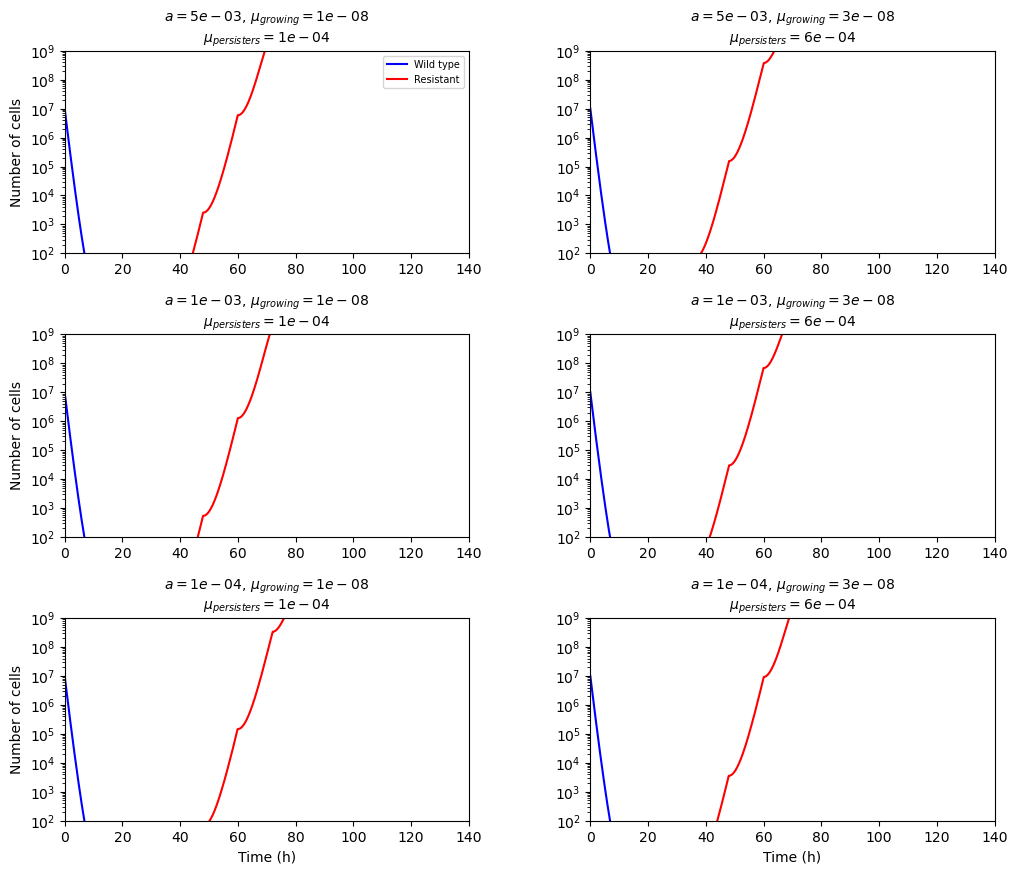

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ------------------------------
# Core Model Functions
# ------------------------------

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g) if g > 0 else 0

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax, gMin = p['gMax'], p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aSwitch = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aSwitch * nw + b * pw - muW * nw - jN * nw * e
    dPw = aSwitch * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aSwitch * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aSwitch * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aSwitch * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aSwitch * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aSwitch * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aSwitch * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

# ------------------------------
# Simulation Grid Setup
# ------------------------------

a_vals = [5e-3, 1e-3, 1e-4]
mutation_sets = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]

t_span = (0, 140)
t_eval = np.linspace(*t_span, 1000)

# Initial conditions: WT = 1e7, R1 = 1 cell only (as stated in supplement)
y0_seeded = [1e7, 0, 1, 0, 0, 0, 0, 0, 0]

replicated_results = {}

for i, a_val in enumerate(a_vals):
    for j, (mu_g, mu_p) in enumerate(mutation_sets):
        params = {
            'mic': [1, 4, 20, 50],
            'gMax': 1.0,
            'gMin': -6.5,
            'kappa': 1,
            'c': 5e9,
            'aMax': a_val,
            'b': 0.1,
            'm': mu_g,
            'tau': 2,
            'h': 5,
            'muP': mu_p,
            'immune': False,  # per Figure 4B
            'mutation': True,
            'emax': 1e6,
            'q': 3e-4,
            'l': 1e-3,
            'jN': 5e-6,
            'jP': 5e-8,
            'aPeak': 25,
            'doseInterval': 12,
            'decayRate': np.log(2) / 2.5
        }
        sol = solve_ivp(system, t_span, y0_seeded, args=(params,), t_eval=t_eval)
        replicated_results[(i, j)] = (sol.t, sol.y)

# ------------------------------
# Plotting the Grid
# ------------------------------

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

for (i, j), (t, y) in replicated_results.items():
    ax = fig.add_subplot(gs[i, j])
    ax.plot(t, y[0], label='Wild type', color='blue')
    ax.plot(t, y[2] + y[4] + y[6], label='Resistant', color='red')
    if i == 0 and j == 0:
        ax.legend(fontsize=7)
    ax.set_yscale('log')
    ax.set_ylim(1e2, 1e9)
    ax.set_xlim(0, t_span[1])
    if i == 2:
        ax.set_xlabel('Time (h)')
    if j == 0:
        ax.set_ylabel('Number of cells')
    a_str = f'{a_vals[i]:.0e}'
    mu_g_str = f'{mutation_sets[j][0]:.0e}'
    mu_p_str = f'{mutation_sets[j][1]:.0e}'
    ax.set_title(f'$a={a_str}$, $\mu_{{growing}}={mu_g_str}$\n$\mu_{{persisters}}={mu_p_str}$', fontsize=10)

plt.tight_layout()
plt.show()


<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2348902043.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.55, 0.85, f'$a={a_str}$\n$\mu_g={mu_g_str}$\n$\mu_p={mu_p_str}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2348902043.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.55, 0.85, f'$a={a_str}$\n$\mu_g={mu_g_str}$\n$\mu_p={mu_p_str}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2348902043.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


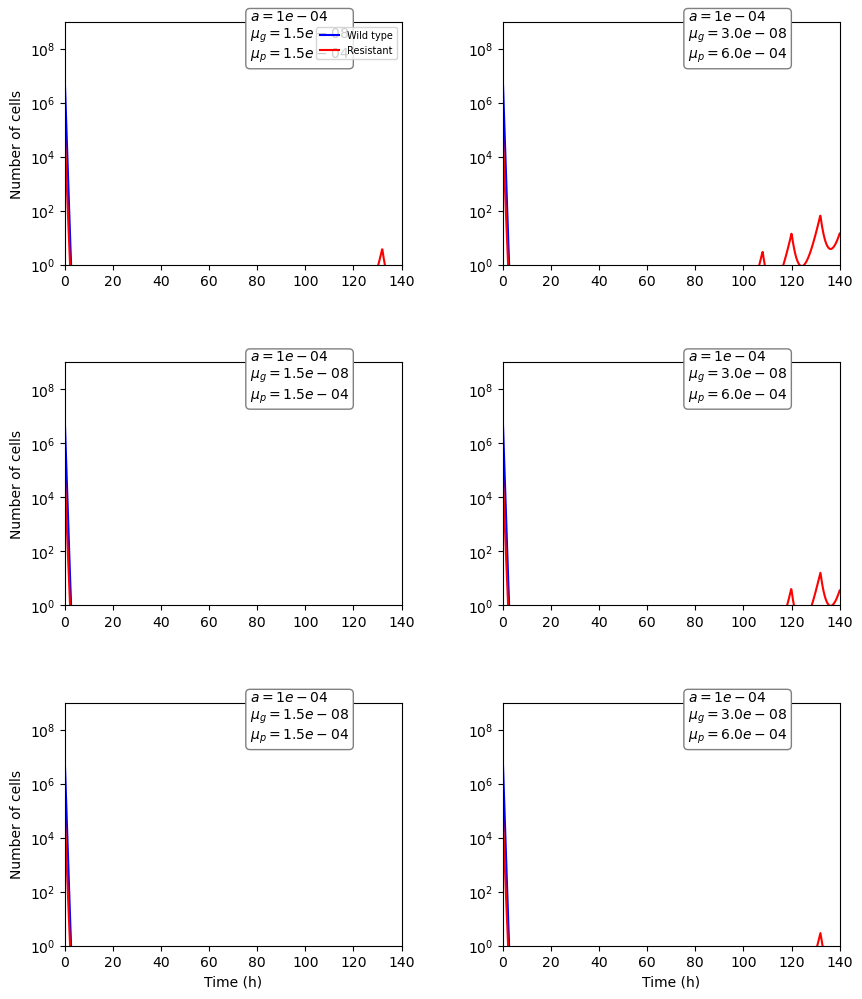

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Core Model Functions ---

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g) if g > 0 else 0

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax, gMin = p['gMax'], p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aSwitch = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aSwitch * nw + b * pw - muW * nw - jN * nw * e
    dPw = aSwitch * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aSwitch * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aSwitch * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aSwitch * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aSwitch * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aSwitch * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aSwitch * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

# --- Simulation Setup (matches Figure 4B) ---

a_vals = [5e-3, 1e-3, 1e-4]
mutation_sets = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]
t_span = (0, 140)
t_eval = np.linspace(*t_span, 1000)

# To rerun with different initial R1 cell counts:
R1_initial = 10e4    # ← change this to 10 or 100 as needed
y0 = [1e7, 0, R1_initial, 0, 0, 0, 0, 0, 0]  # NW = 1e7, NR1 = R1_initial

fig4b_results = {}

for i, a in enumerate(a_vals):
    for j, (mu_g, mu_p) in enumerate(mutation_sets):
        params = {
            'mic': [1, 4, 20, 50],
            'gMax': 1.0,
            'gMin': -6.5,
            'kappa': 1,
            'c': 5e9,
            'aMax': a,
            'b': 0.1,
            'm': mu_g,
            'tau': 2,
            'h': 5,
            'muP': mu_p,
            'immune': False,
            'mutation': True,
            'emax': 1e6,
            'q': 3e-4,
            'l': 1e-3,
            'jN': 5e-6,
            'jP': 5e-8,
            'aPeak': 25,
            'doseInterval': 12,
            'decayRate': np.log(2) / 2.5
        }
        sol = solve_ivp(system, t_span, y0, args=(params,), t_eval=t_eval)
        fig4b_results[(i, j)] = (sol.t, sol.y)

# --- Plotting Figure 4B Style ---

fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

for (i, j), (t, y) in fig4b_results.items():
    ax = fig.add_subplot(gs[i, j])
    ax.plot(t, y[0], label='Wild type', color='blue')
    ax.plot(t, y[2] + y[4] + y[6], label='Resistant', color='red')
    ax.set_yscale('log')
    ax.set_ylim(1, 1e9)
    ax.set_xlim(0, 140)
    if i == 2:
        ax.set_xlabel('Time (h)')
    if j == 0:
        ax.set_ylabel('Number of cells')
    if i == 0 and j == 0:
        ax.legend(fontsize=7, loc='upper right')
    a_str = f'{a:.0e}'
    mu_g_str = f'{mutation_sets[j][0]:.1e}'
    mu_p_str = f'{mutation_sets[j][1]:.1e}'
    ax.text(0.55, 0.85, f'$a={a_str}$\n$\mu_g={mu_g_str}$\n$\mu_p={mu_p_str}$',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()


/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1714162112.py:49: RuntimeWarning: overflow encountered in exp
  return m * g + tau * m * np.exp(-h * g)
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1714162112.py:57: RuntimeWarning: invalid value encountered in scalar add
  total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1714162112.py:75: RuntimeWarning: invalid value encountered in scalar multiply
  dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1714162112.py:77: RuntimeWarning: invalid value encountered in scalar multiply
  dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1714162112.py:79: RuntimeWarning: invalid value encountered in scalar multiply
  dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - mu

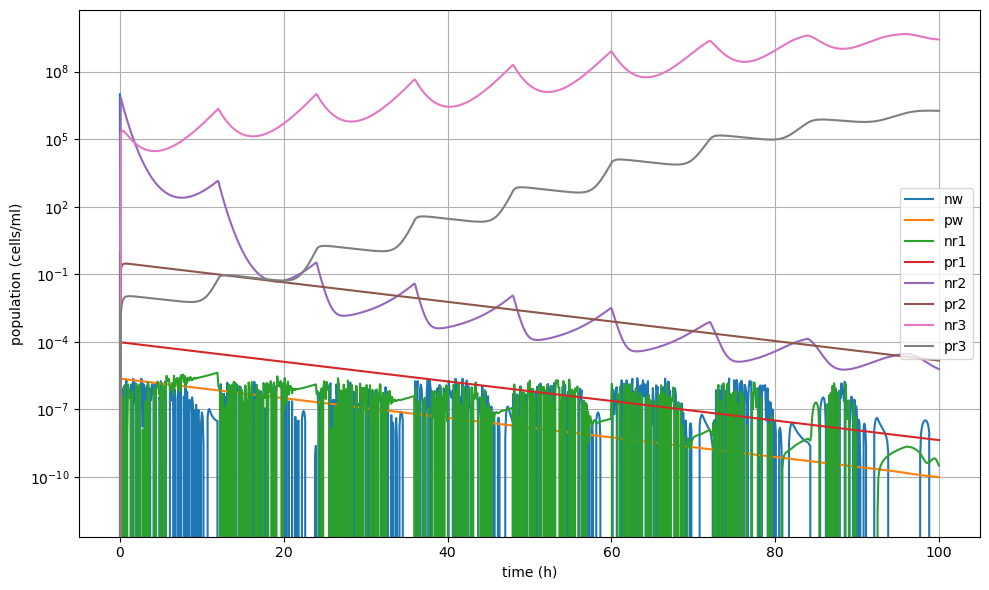

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],      # MIC values for wildtype and 3 resistant mutants
    'gMax': 1.0,                # Max growth rate of WT cells
    'gMin': -6.5,               # Minimum growth rate (when antibiotic is fully inhibitory)
    'gMaxR': 0.9,               # Max growth rate of Resister cells
    'kappa': 1,                 # Hill coefficient for drug effect
    'c': 5e9,                   # Carrying capacity
    'aMax': 1e-4,               # Rate of conversion from N to P under drug exposure
    'b': 0.1,                   # Rate of reversion from P to N
    'm': 1.5e-8,                # Basal mutation rate
    'tau': 2,                   # Coefficient for stress-induced mutagenesis
    'h': 5,                     # Exponent for stress response curve
    'muP': 1.5e-4,              # Mutation rate from persisters
    'immune': False,             # Whether immune response is enabled
    'mutation': True,           # Whether mutation is enabled
    'emax': 1e6,                # Max immune effector population
    'q': 3e-4,                  # Immune recruitment rate
    'l': 1e-3,                  # Immune inactivation rate
    'jN': 5e-6,                 # Immune killing of normal cells
    'jP': 5e-8,                 # Immune killing of persisters
    'aPeak': 25,                # Peak antibiotic concentration
    'doseInterval': 12,         # Antibiotic dosing interval (hours)
    'decayRate': np.log(2)/2.5  # Drug decay rate (half-life = 2.5h)
}

def drug(t, decayRate, doseInterval, aPeak):
    # Current drug concentration
    return aPeak * np.exp(-decayRate * (t % doseInterval))

# def drug(t, decayRate, doseInterval, aPeak):
#     num_doses = int((t - doseInterval) // doseInterval) + 1
#     dose_times = doseInterval + np.arange(num_doses) * doseInterval
#     return np.sum(aPeak * np.exp(-decayRate * (t - dose_times)))
        
# def growthRate(a, mic, gMax, gMin, kappa):
#     # Growth inhibition
#     return gMax - ((gMax - gMin) * (a/mic)**kappa / ((a/mic)**kappa - (gMin/gMax)))


def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    # Stress induced mutation rate 
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMaxR = p['gMax']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak']) # Drug concentration
    aRate = p['aMax'] * total / p['c'] # Drug induced switching to persisters
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e7, 0, 1, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


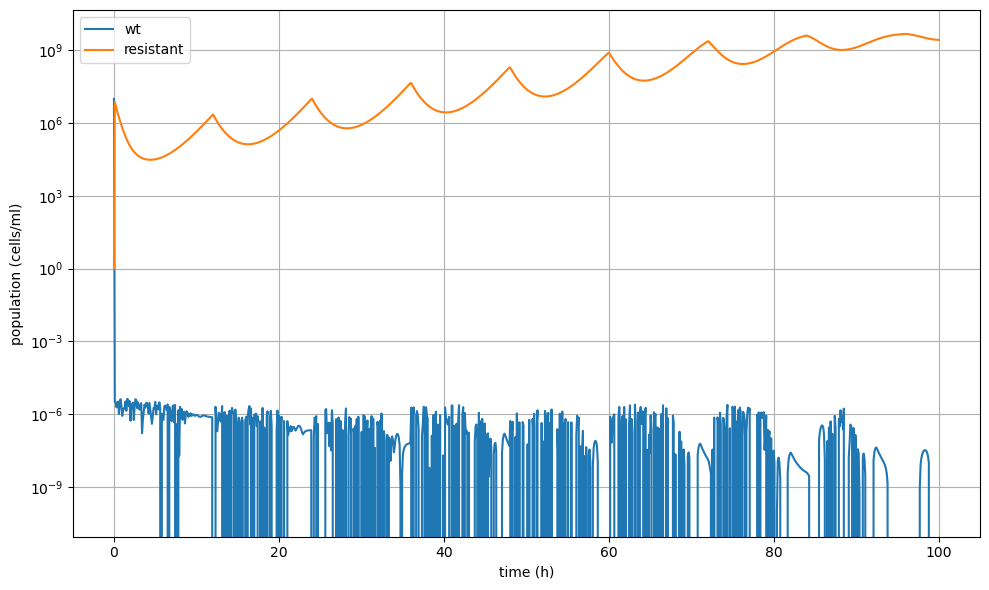

In [ ]:
wt_total = sol.y[0] + sol.y[1]
rs_total = sol.y[2] + sol.y[3] + sol.y[5] + sol.y[6] + sol.y[7] + sol.y[4]

plt.figure(figsize=(10, 6))
plt.plot(sol.t, wt_total, label='wt')
plt.plot(sol.t, rs_total, label='resistant')
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1203982988.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.55, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1203982988.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.55, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1203982988.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


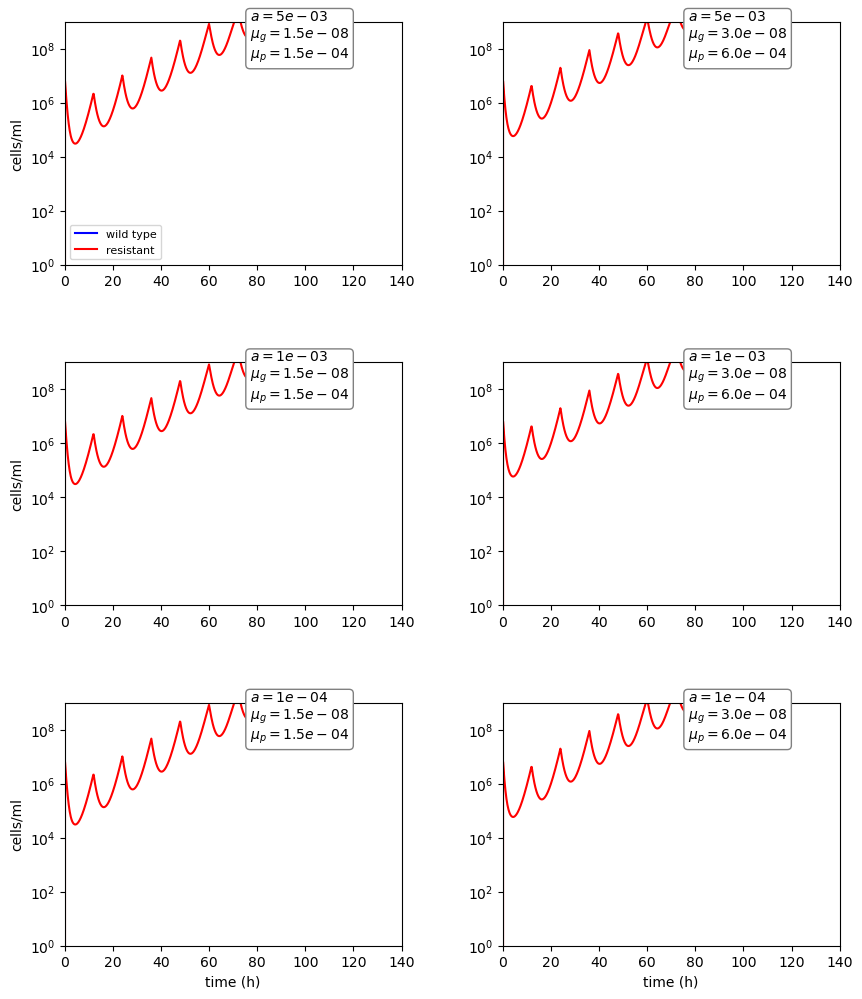

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0
    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0
    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

baseParams = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': None,
    'b': 0.1,
    'm': None,
    'tau': 2,
    'h': 5,
    'muP': None,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2) / 2.5
}

aVals = [5e-3, 1e-3, 1e-4]
mutationVals = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]
tSpan = (0, 140)
tEval = np.linspace(*tSpan, 1000)
y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]

results = {}
for i, a in enumerate(aVals):
    for j, (muG, muP) in enumerate(mutationVals):
        p = baseParams.copy()
        p['aMax'] = a
        p['m'] = muG
        p['muP'] = muP
        sol = solve_ivp(system, tSpan, y0, args=(p,), t_eval=tEval, method='LSODA')
        yClipped = np.clip(sol.y, 0, None)
        results[(i, j)] = (sol.t, yClipped)


fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

for (i, j), (t, y) in results.items():
    ax = fig.add_subplot(gs[i, j])
    wtTotal = y[0] + y[1]
    rsTotal = y[2] + y[3] + y[4] + y[5] + y[6] + y[7]
    ax.plot(t, wtTotal, label='wild type', color='blue')
    ax.plot(t, rsTotal, label='resistant', color='red')
    ax.set_yscale('log')
    ax.set_ylim(1, 1e9)
    ax.set_xlim(*tSpan)
    if i == 2:
        ax.set_xlabel('time (h)')
    if j == 0:
        ax.set_ylabel('cells/ml')
    if i == 0 and j == 0:
        ax.legend(fontsize=8)
    aStr = f'{aVals[i]:.0e}'
    muGStr = f'{mutationVals[j][0]:.1e}'
    muPStr = f'{mutationVals[j][1]:.1e}'
    ax.text(0.55, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()


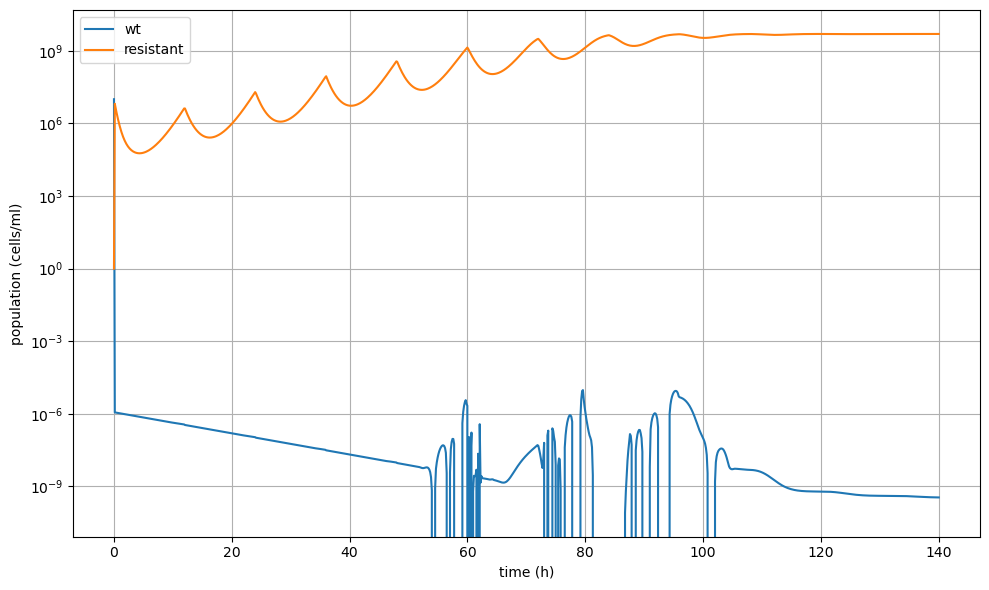

In [ ]:
wt_total = sol.y[0] + sol.y[1]
rs_total = sol.y[2] + sol.y[3] + sol.y[5] + sol.y[6] + sol.y[7] + sol.y[4]

plt.figure(figsize=(10, 6))
plt.plot(sol.t, wt_total, label='wt')
plt.plot(sol.t, rs_total, label='resistant')
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

sams code

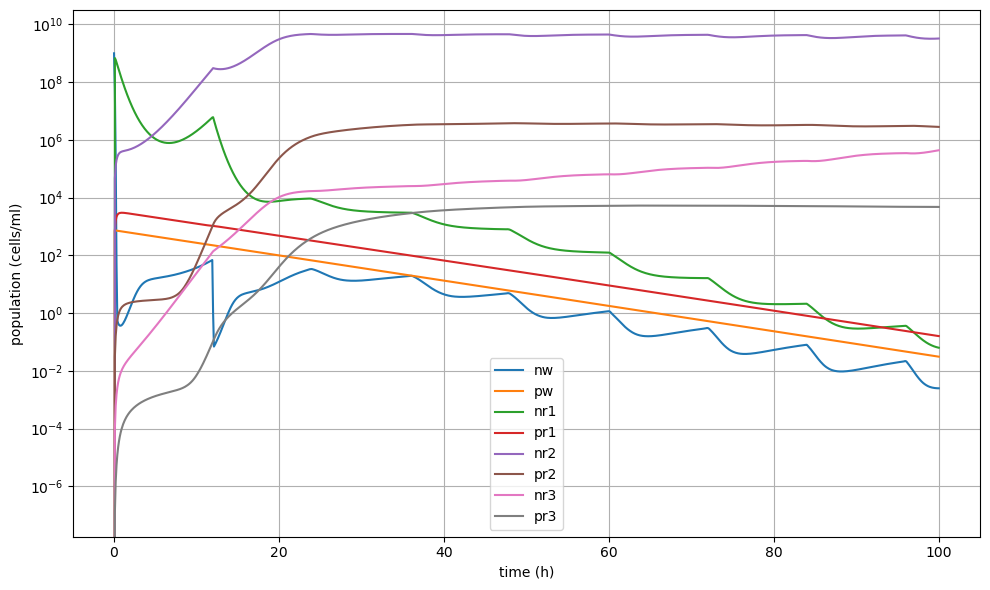

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],      # MIC values for wildtype and 3 resistant mutants
    'gMax': 1.0,                # Max growth rate of WT cells
    'gMin': -6.5,               # Minimum growth rate (when antibiotic is fully inhibitory)
    'gMaxR': 0.9,               # Max growth rate of Resister cells
    'kappa': 1,                 # Hill coefficient for drug effect
    'c': 5e9,                   # Carrying capacity
    'aMax': 1e-4,               # Rate of conversion from N to P under drug exposure
    'b': 0.1,                   # Rate of reversion from P to N
    'm': 1.5e-8,                # Basal mutation rate
    'tau': 2,                   # Coefficient for stress-induced mutagenesis
    'h': 5,                     # Exponent for stress response curve
    'muP': 1.5e-4,              # Mutation rate from persisters
    'immune': True,             # Whether immune response is enabled
    'mutation': True,           # Whether mutation is enabled
    'emax': 1e6,                # Max immune effector population
    'q': 3e-4,                  # Immune recruitment rate
    'l': 1e-3,                  # Immune inactivation rate
    'jN': 5e-6,                 # Immune killing of normal cells
    'jP': 5e-8,                 # Immune killing of persisters
    'aPeak': 25,                # Peak antibiotic concentration
    'doseInterval': 12,         # Antibiotic dosing interval (hours)
    'decayRate': np.log(2)/2.5  # Drug decay rate (half-life = 2.5h)
}

def drug(t, decayRate, doseInterval, aPeak):
    # Current drug concentration
    return aPeak * np.exp(-decayRate * (t % doseInterval))

# def drug(t, decayRate, doseInterval, aPeak):
#     num_doses = int((t - doseInterval) // doseInterval) + 1
#     dose_times = doseInterval + np.arange(num_doses) * doseInterval
#     return np.sum(aPeak * np.exp(-decayRate * (t - dose_times)))
        
def growthRate(a, mic, gMax, gMin, kappa):
    # Growth inhibition
    return gMax - ((gMax - gMin) * (a/mic)**kappa / ((a/mic)**kappa - (gMin/gMax)))

def mutationRate(g, m, tau, h):
    # Stress induced mutation rate 
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMaxR = p['gMaxR']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak']) # Drug concentration
    aRate = p['aMax'] * total / p['c'] # Drug induced switching to persisters
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e9, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


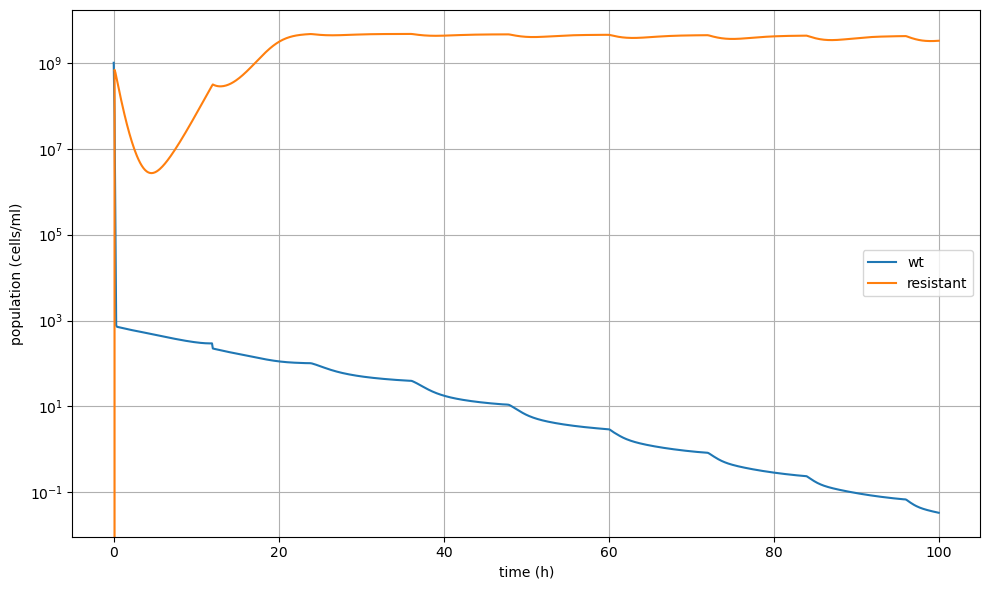

In [ ]:
wt_total = sol.y[0] + sol.y[1]
rs_total = sol.y[2] + sol.y[3] + sol.y[5] + sol.y[6] + sol.y[7] + sol.y[4]

plt.figure(figsize=(10, 6))
plt.plot(sol.t, wt_total, label='wt')
plt.plot(sol.t, rs_total, label='resistant')
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1203982988.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.55, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1203982988.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.55, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1203982988.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


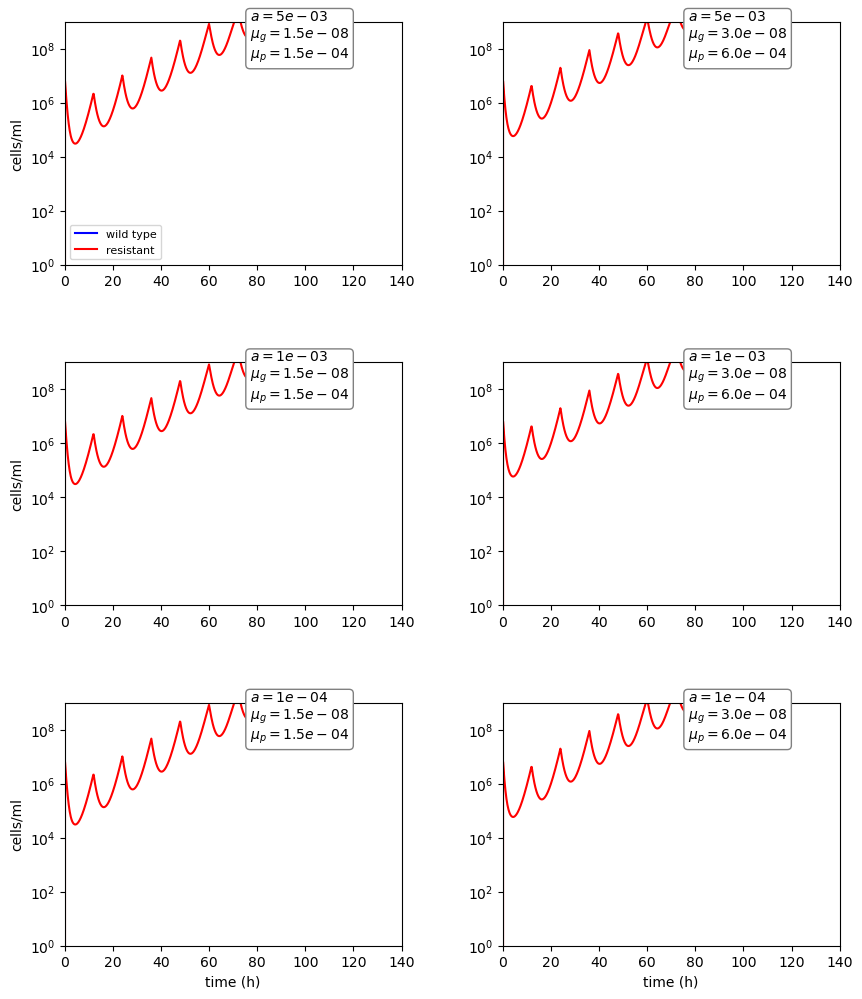

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

for (i, j), (t, y) in results.items():
    ax = fig.add_subplot(gs[i, j])
    wtTotal = y[0] + y[1]
    rsTotal = y[2] + y[3] + y[4] + y[5] + y[6] + y[7]
    ax.plot(t, wtTotal, label='wild type', color='blue')
    ax.plot(t, rsTotal, label='resistant', color='red')
    ax.set_yscale('log')
    ax.set_ylim(1, 1e9)
    ax.set_xlim(*tSpan)
    if i == 2:
        ax.set_xlabel('time (h)')
    if j == 0:
        ax.set_ylabel('cells/ml')
    if i == 0 and j == 0:
        ax.legend(fontsize=8)
    aStr = f'{aVals[i]:.0e}'
    muGStr = f'{mutationVals[j][0]:.1e}'
    muPStr = f'{mutationVals[j][1]:.1e}'
    ax.text(0.55, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()


me using sams code

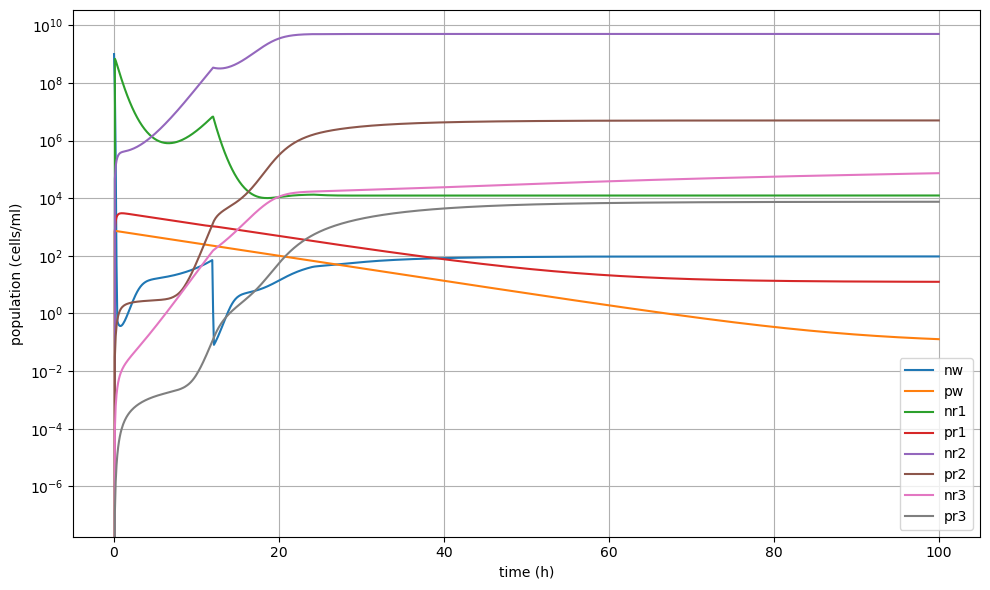

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],      # MIC values for wildtype and 3 resistant mutants
    'gMax': 1.0,                # Max growth rate of WT cells
    'gMin': -6.5,               # Minimum growth rate (when antibiotic is fully inhibitory)
    'gMaxR': 0.9,               # Max growth rate of Resister cells
    'kappa': 1,                 # Hill coefficient for drug effect
    'c': 5e9,                   # Carrying capacity
    'aMax': 1e-4,               # Rate of conversion from N to P under drug exposure
    'b': 0.1,                   # Rate of reversion from P to N
    'm': 1.5e-8,                # Basal mutation rate
    'tau': 2,                   # Coefficient for stress-induced mutagenesis
    'h': 5,                     # Exponent for stress response curve
    'muP': 1.5e-4,              # Mutation rate from persisters
    'immune': False,             # Whether immune response is enabled
    'mutation': True,           # Whether mutation is enabled
    'emax': 1e6,                # Max immune effector population
    'q': 3e-4,                  # Immune recruitment rate
    'l': 1e-3,                  # Immune inactivation rate
    'jN': 5e-6,                 # Immune killing of normal cells
    'jP': 5e-8,                 # Immune killing of persisters
    'aPeak': 25,                # Peak antibiotic concentration
    'doseInterval': 12,         # Antibiotic dosing interval (hours)
    'decayRate': np.log(2)/2.5  # Drug decay rate (half-life = 2.5h)
}

def drug(t, decayRate, doseInterval, aPeak):
    # Current drug concentration
    return aPeak * np.exp(-decayRate * (t % doseInterval))

# def drug(t, decayRate, doseInterval, aPeak):
#     num_doses = int((t - doseInterval) // doseInterval) + 1
#     dose_times = doseInterval + np.arange(num_doses) * doseInterval
#     return np.sum(aPeak * np.exp(-decayRate * (t - dose_times)))
        
def growthRate(a, mic, gMax, gMin, kappa):
    # Growth inhibition
    return gMax - ((gMax - gMin) * (a/mic)**kappa / ((a/mic)**kappa - (gMin/gMax)))

def mutationRate(g, m, tau, h):
    # Stress induced mutation rate 
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMaxR = p['gMaxR']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak']) # Drug concentration
    aRate = p['aMax'] * total / p['c'] # Drug induced switching to persisters
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e9, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


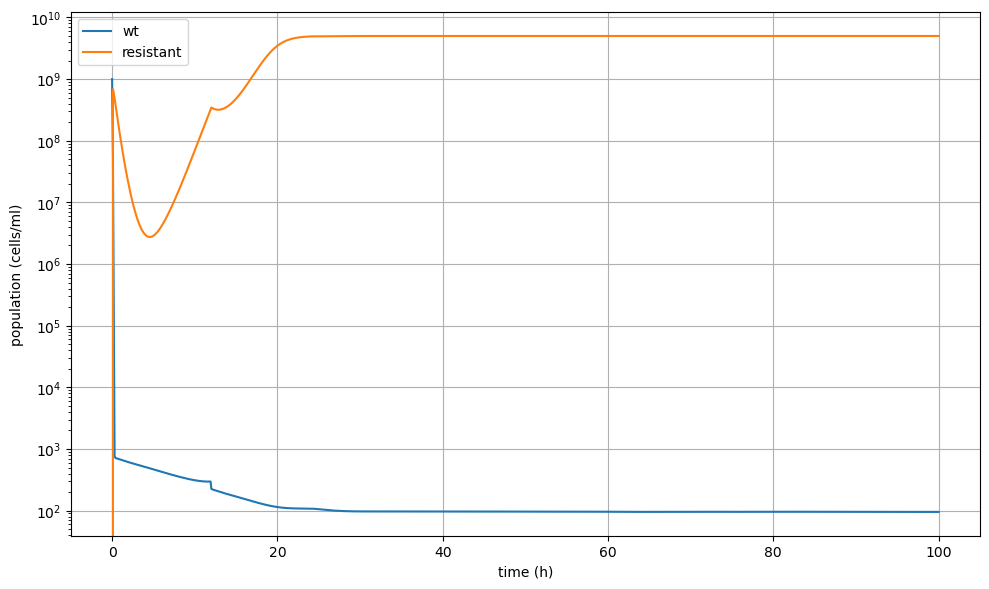

In [ ]:
wt_total = sol.y[0] + sol.y[1]
rs_total = sol.y[2] + sol.y[3] + sol.y[5] + sol.y[6] + sol.y[7] + sol.y[4]

plt.figure(figsize=(10, 6))
plt.plot(sol.t, wt_total, label='wt')
plt.plot(sol.t, rs_total, label='resistant')
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/148736481.py:104: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/148736481.py:104: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',


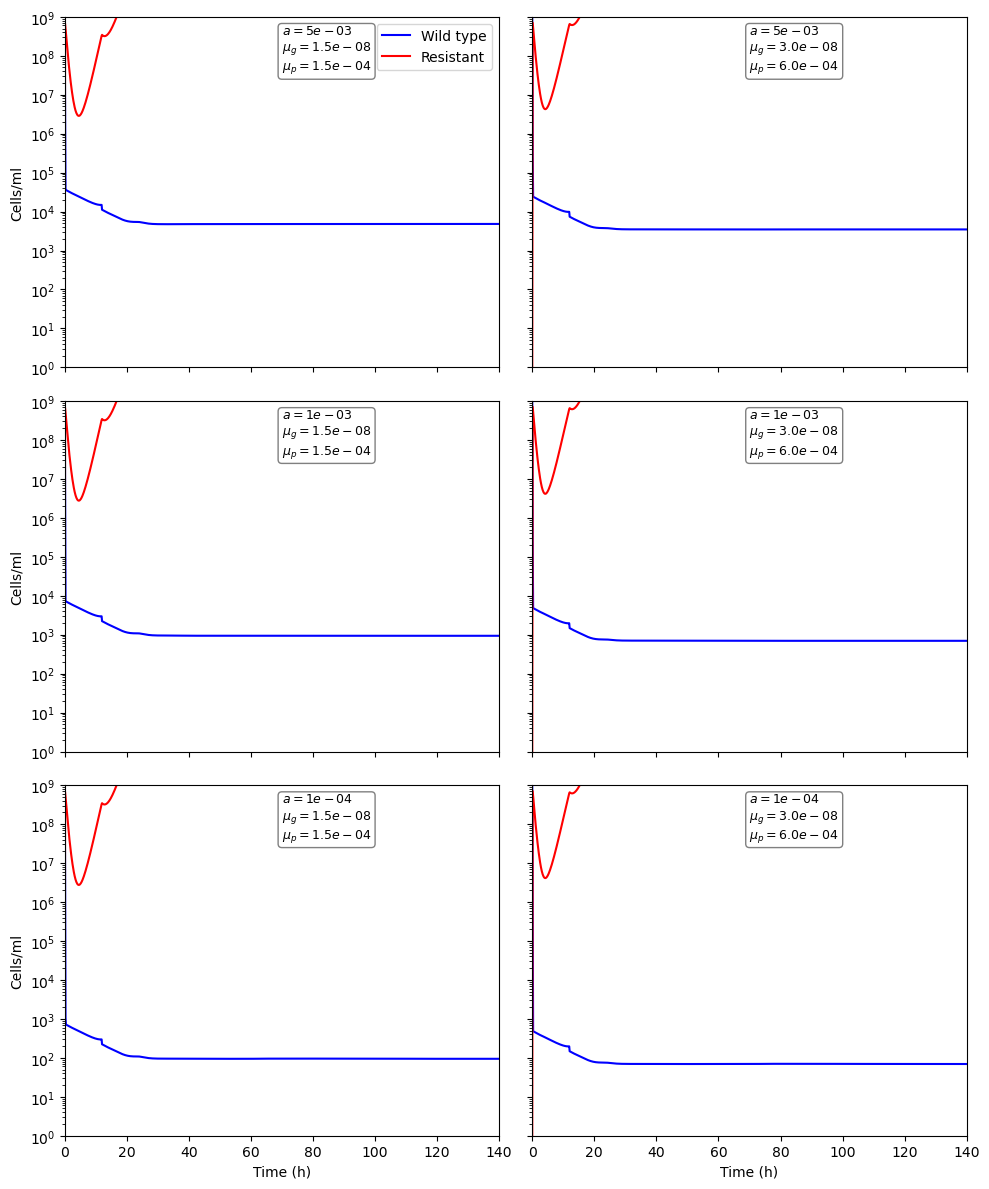

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - ((gMax - gMin) * (a/mic)**kappa / ((a/mic)**kappa - (gMin/gMax)))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    gMaxR = p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0
    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0
    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

baseParams = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': None,
    'b': 0.1,
    'm': None,
    'tau': 2,
    'h': 5,
    'muP': None,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2)/2.5
}

aVals = [5e-3, 1e-3, 1e-4]  # top to bottom (higher persister switching)
mutationVals = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]  # left to right (higher mutation rates)
tSpan = (0, 140)
tEval = np.linspace(*tSpan, 1000)
y0 = [1e9, 0, 1, 0, 0, 0, 0, 0, 0]  # Start only WT, let resistance emerge

fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for i, a in enumerate(aVals):
    for j, (muG, muP) in enumerate(mutationVals):
        p = baseParams.copy()
        p['aMax'] = a
        p['m'] = muG
        p['muP'] = muP
        sol = solve_ivp(system, tSpan, y0, args=(p,), t_eval=tEval, method='LSODA')
        y = np.clip(sol.y, 1e-6, None)
        t = sol.t
        wt = y[0] + y[1]
        rs = y[2] + y[3] + y[4] + y[5] + y[6] + y[7]
        ax = axs[i, j]
        ax.plot(t, wt, color='blue', label='Wild type')
        ax.plot(t, rs, color='red', label='Resistant')
        ax.set_yscale('log')
        ax.set_ylim(1, 1e9)
        ax.set_xlim(*tSpan)
        if i == 2:
            ax.set_xlabel('Time (h)')
        if j == 0:
            ax.set_ylabel('Cells/ml')
        if i == 0 and j == 0:
            ax.legend()
        aStr = f'{a:.0e}'
        muGStr = f'{muG:.1e}'
        muPStr = f'{muP:.1e}'
        ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()


<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2988802805.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/2988802805.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',


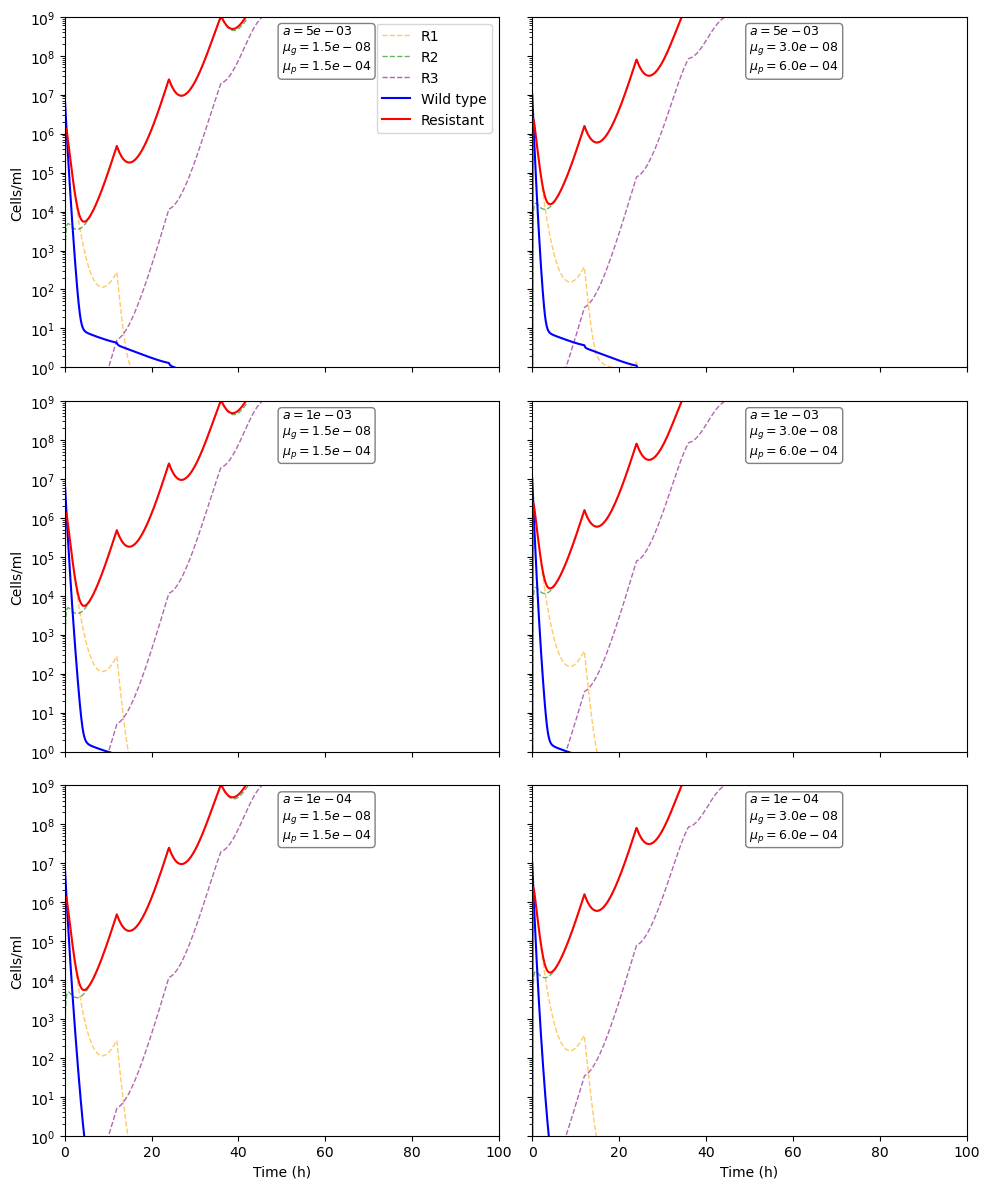

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    gMaxR = p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0
    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0
    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

baseParams = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -4.0,
    'kappa': 1,
    'c': 5e9,
    'aMax': None,
    'b': 0.1,
    'm': None,
    'tau': 2,
    'h': 5,
    'muP': None,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 10,
    'doseInterval': 12,
    'decayRate': np.log(2)/2.5
}

aVals = [5e-3, 1e-3, 1e-4]
mutationVals = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)
y0 = [1e7, 0, 1, 0, 0, 0, 0, 0, 0]

fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for i, a in enumerate(aVals):
    for j, (muG, muP) in enumerate(mutationVals):
        p = baseParams.copy()
        p['aMax'] = a
        p['m'] = muG
        p['muP'] = muP
        sol = solve_ivp(system, tSpan, y0, args=(p,), t_eval=tEval, method='LSODA')
        t = sol.t
        y = sol.y

        wt = np.clip(y[0] + y[1], 1e-6, None)
        rs = np.clip(y[2] + y[3] + y[4] + y[5] + y[6] + y[7], 1e-6, None)
        r1 = np.clip(y[2] + y[3], 1e-6, None)
        r2 = np.clip(y[4] + y[5], 1e-6, None)
        r3 = np.clip(y[6] + y[7], 1e-6, None)

        ax = axs[i, j]
        ax.plot(t, r1, '--', color='orange', linewidth=1, alpha=0.6, label='R1' if i == 0 and j == 0 else None)
        ax.plot(t, r2, '--', color='green', linewidth=1, alpha=0.6, label='R2' if i == 0 and j == 0 else None)
        ax.plot(t, r3, '--', color='purple', linewidth=1, alpha=0.6, label='R3' if i == 0 and j == 0 else None)
        ax.plot(t, wt, color='blue', label='Wild type' if i == 0 and j == 0 else None)
        ax.plot(t, rs, color='red', label='Resistant' if i == 0 and j == 0 else None)

        ax.set_yscale('log')
        ax.set_ylim(1, 1e9)
        ax.set_xlim(*tSpan)
        if i == 2:
            ax.set_xlabel('Time (h)')
        if j == 0:
            ax.set_ylabel('Cells/ml')
        if i == 0 and j == 0:
            ax.legend()
        aStr = f'{a:.0e}'
        muGStr = f'{muG:.1e}'
        muPStr = f'{muP:.1e}'
        ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()

<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1501336626.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1501336626.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',


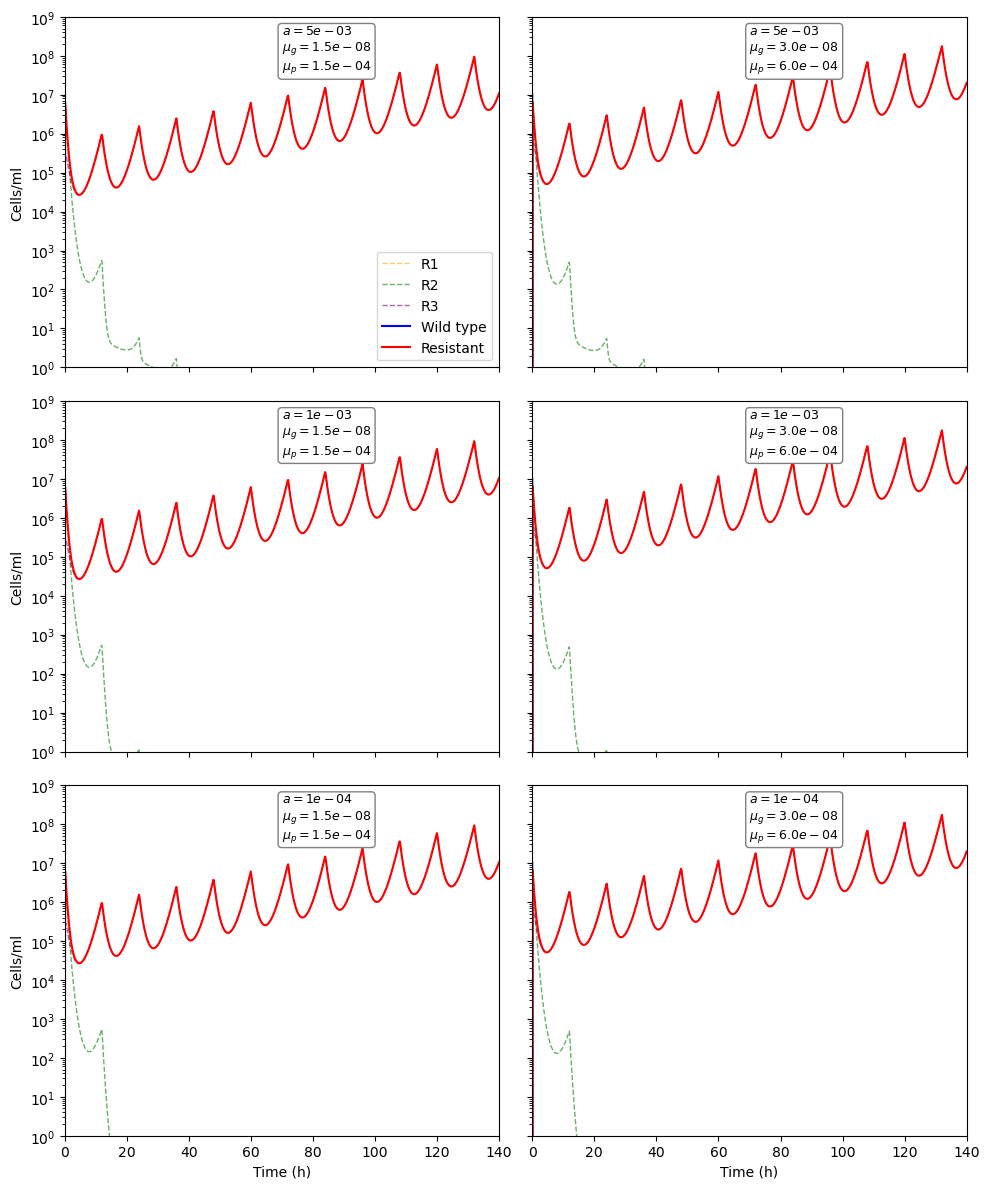

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    gMaxR = p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0
    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0
    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

baseParams = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': None,
    'b': 0.1,
    'm': None,
    'tau': 2,
    'h': 5,
    'muP': None,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2)/2.5
}

aVals = [5e-3, 1e-3, 1e-4]
mutationVals = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]
tSpan = (0, 140)
tEval = np.linspace(*tSpan, 1000)
y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]

fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for i, a in enumerate(aVals):
    for j, (muG, muP) in enumerate(mutationVals):
        p = baseParams.copy()
        p['aMax'] = a
        p['m'] = muG
        p['muP'] = muP
        sol = solve_ivp(system, tSpan, y0, args=(p,), t_eval=tEval, method='LSODA')
        t = sol.t
        y = sol.y

        wt = np.clip(y[0] + y[1], 1e-6, None)
        rs = np.clip(y[2] + y[3] + y[4] + y[5] + y[6] + y[7], 1e-6, None)
        r1 = np.clip(y[2] + y[3], 1e-6, None)
        r2 = np.clip(y[4] + y[5], 1e-6, None)
        r3 = np.clip(y[6] + y[7], 1e-6, None)

        ax = axs[i, j]
        ax.plot(t, r1, '--', color='orange', linewidth=1, alpha=0.6, label='R1' if i == 0 and j == 0 else None)
        ax.plot(t, r2, '--', color='green', linewidth=1, alpha=0.6, label='R2' if i == 0 and j == 0 else None)
        ax.plot(t, r3, '--', color='purple', linewidth=1, alpha=0.6, label='R3' if i == 0 and j == 0 else None)
        ax.plot(t, wt, color='blue', label='Wild type' if i == 0 and j == 0 else None)
        ax.plot(t, rs, color='red', label='Resistant' if i == 0 and j == 0 else None)

        ax.set_yscale('log')
        ax.set_ylim(1, 1e9)
        ax.set_xlim(*tSpan)
        if i == 2:
            ax.set_xlabel('Time (h)')
        if j == 0:
            ax.set_ylabel('Cells/ml')
        if i == 0 and j == 0:
            ax.legend()
        aStr = f'{a:.0e}'
        muGStr = f'{muG:.1e}'
        muPStr = f'{muP:.1e}'
        ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()


<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1872402672.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/1872402672.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',


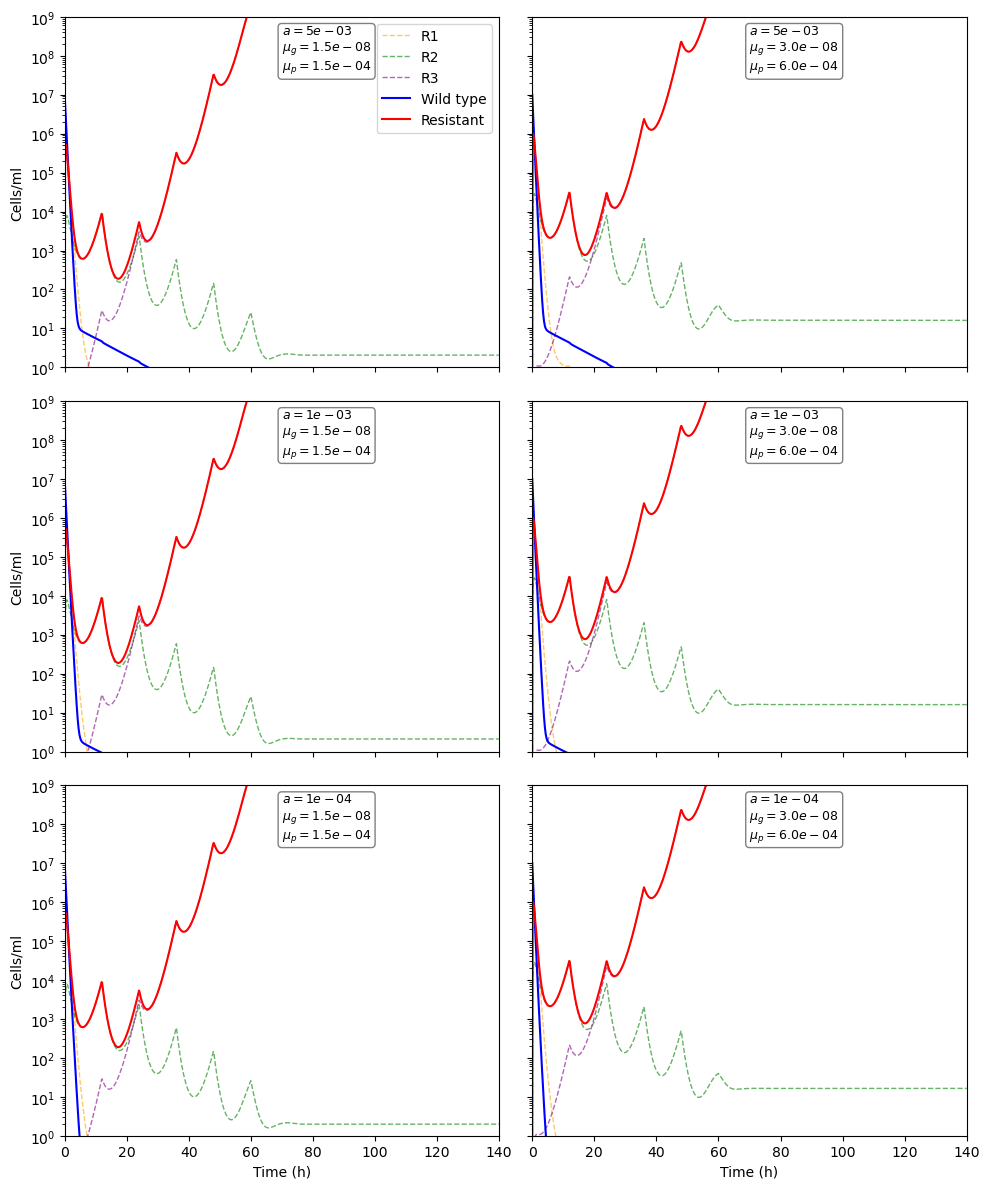

In [121]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    return m * max(g, 0) + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    gMaxR = p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0
    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0
    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

baseParams = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -3.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': None,
    'b': 0.1,
    'm': None,
    'tau': 2,
    'h': 5,
    'muP': None,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2)/2.5
}

aVals = [5e-3, 1e-3, 1e-4]
mutationVals = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]
tSpan = (0, 140)
tEval = np.linspace(*tSpan, 1000)
y0 = [1e7, 0, 1, 0, 0, 0, 0, 0, 0]

fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for i, a in enumerate(aVals):
    for j, (muG, muP) in enumerate(mutationVals):
        p = baseParams.copy()
        p['aMax'] = a
        p['m'] = muG
        p['muP'] = muP
        sol = solve_ivp(system, tSpan, y0, args=(p,), t_eval=tEval, method='LSODA')
        t = sol.t
        y = sol.y

        wt = np.clip(y[0] + y[1], 1e-6, None)
        rs = np.clip(y[2] + y[3] + y[4] + y[5] + y[6] + y[7], 1e-6, None)
        r1 = np.clip(y[2] + y[3], 1e-6, None)
        r2 = np.clip(y[4] + y[5], 1e-6, None)
        r3 = np.clip(y[6] + y[7], 1e-6, None)

        ax = axs[i, j]
        ax.plot(t, r1, '--', color='orange', linewidth=1, alpha=0.6, label='R1' if i == 0 and j == 0 else None)
        ax.plot(t, r2, '--', color='green', linewidth=1, alpha=0.6, label='R2' if i == 0 and j == 0 else None)
        ax.plot(t, r3, '--', color='purple', linewidth=1, alpha=0.6, label='R3' if i == 0 and j == 0 else None)
        ax.plot(t, wt, color='blue', label='Wild type' if i == 0 and j == 0 else None)
        ax.plot(t, rs, color='red', label='Resistant' if i == 0 and j == 0 else None)

        ax.set_yscale('log')
        ax.set_ylim(1, 1e9)
        ax.set_xlim(*tSpan)
        if i == 2:
            ax.set_xlabel('Time (h)')
        if j == 0:
            ax.set_ylabel('Cells/ml')
        if i == 0 and j == 0:
            ax.legend()
        aStr = f'{a:.0e}'
        muGStr = f'{muG:.1e}'
        muPStr = f'{muP:.1e}'
        ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()

fix drug fn

<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/3137906686.py:114: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_70090/3137906686.py:114: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',


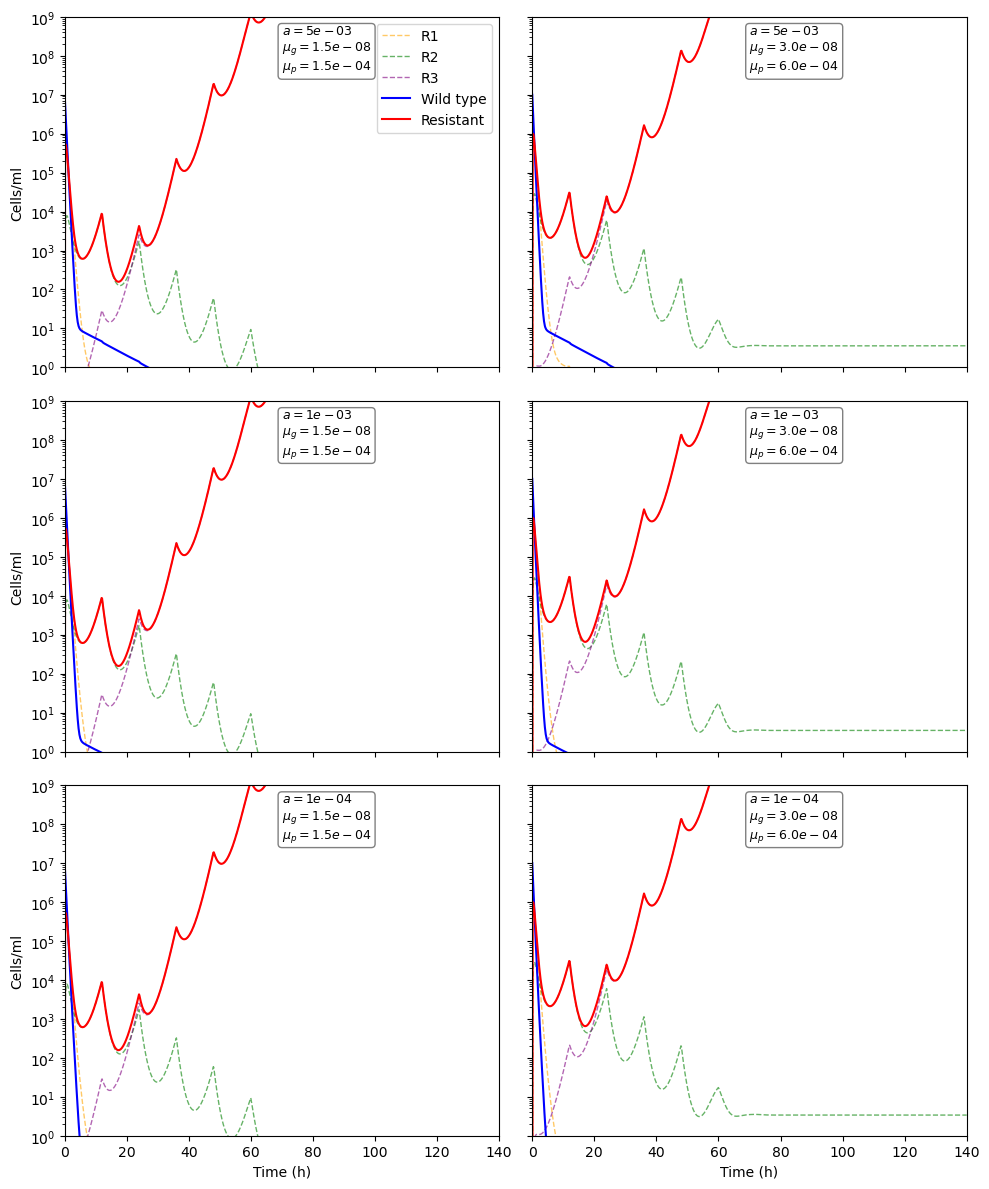

In [146]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def drug(t, decayRate, doseInterval, aPeak):
    dose_times = np.arange(0, t + 1, doseInterval)
    return np.sum([aPeak * np.exp(-decayRate * (t - d)) for d in dose_times if d <= t])

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    return m * max(g, 0) + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    gMaxR = p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0
    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0
    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

baseParams = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -3.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': None,
    'b': 0.1,
    'm': None,
    'tau': 2,
    'h': 5,
    'muP': None,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2)/2.5
}

aVals = [5e-3, 1e-3, 1e-4]
mutationVals = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]
tSpan = (0, 140)
tEval = np.linspace(*tSpan, 1000)
y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]

fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for i, a in enumerate(aVals):
    for j, (muG, muP) in enumerate(mutationVals):
        p = baseParams.copy()
        p['aMax'] = a
        p['m'] = muG
        p['muP'] = muP
        sol = solve_ivp(system, tSpan, y0, args=(p,), t_eval=tEval, method='LSODA')
        t = sol.t
        y = sol.y

        wt = np.clip(y[0] + y[1], 1e-6, None)
        rs = np.clip(y[2] + y[3] + y[4] + y[5] + y[6] + y[7], 1e-6, None)
        r1 = np.clip(y[2] + y[3], 1e-6, None)
        r2 = np.clip(y[4] + y[5], 1e-6, None)
        r3 = np.clip(y[6] + y[7], 1e-6, None)

        ax = axs[i, j]
        ax.plot(t, r1, '--', color='orange', linewidth=1, alpha=0.6, label='R1' if i == 0 and j == 0 else None)
        ax.plot(t, r2, '--', color='green', linewidth=1, alpha=0.6, label='R2' if i == 0 and j == 0 else None)
        ax.plot(t, r3, '--', color='purple', linewidth=1, alpha=0.6, label='R3' if i == 0 and j == 0 else None)
        ax.plot(t, wt, color='blue', label='Wild type' if i == 0 and j == 0 else None)
        ax.plot(t, rs, color='red', label='Resistant' if i == 0 and j == 0 else None)

        ax.set_yscale('log')
        ax.set_ylim(1, 1e9)
        ax.set_xlim(*tSpan)
        if i == 2:
            ax.set_xlabel('Time (h)')
        if j == 0:
            ax.set_ylabel('Cells/ml')
        if i == 0 and j == 0:
            ax.legend()
        aStr = f'{a:.0e}'
        muGStr = f'{muG:.1e}'
        muPStr = f'{muP:.1e}'
        ax.text(0.5, 0.85, f'$a={aStr}$\n$\mu_g={muGStr}$\n$\mu_p={muPStr}$',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()

try diff initial conditions and wt growth suppression logic

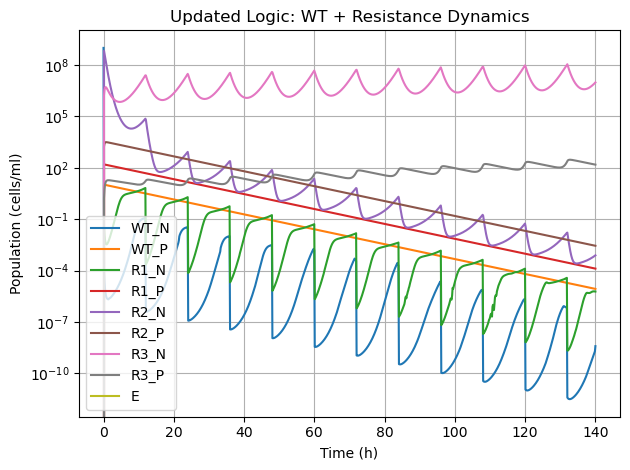

In [147]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def drug(t, decayRate, doseInterval, aPeak):
    dose_times = np.arange(0, t + 1, doseInterval)
    return np.sum([aPeak * np.exp(-decayRate * (t - d)) for d in dose_times if d <= t])

def growthRate(a, mic, gMax, gMin, kappa):
    ratio = a / mic
    return gMax - (gMax - gMin) * (ratio**kappa / (ratio**kappa + 1))

def mutationRate(g, m, tau, h):
    safe_exp = np.exp(-h * g) if g < 100 else 0  # prevent overflow
    return m * max(g, 0) + tau * m * safe_exp

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax, gMin, gMaxR = p['gMax'], p['gMin'], p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

# Parameters
params = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': 1e-4,
    'b': 0.1,
    'm': 1.5e-8,
    'tau': 2,
    'h': 5,
    'muP': 1.5e-4,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2)/2.5
}

# Initial state: all WT, no resistant clones
y0 = [1e9, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 140)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='LSODA')

labels = ['WT_N', 'WT_P', 'R1_N', 'R1_P', 'R2_N', 'R2_P', 'R3_N', 'R3_P', 'E']
for i, label in enumerate(labels):
    plt.plot(sol.t, sol.y[i], label=label)
plt.yscale('log')
plt.xlabel('Time (h)')
plt.ylabel('Population (cells/ml)')
plt.title('Updated Logic: WT + Resistance Dynamics')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:112: SyntaxWarning: invalid escape sequence '\m'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_2792/2405294208.py:112: SyntaxWarning: invalid escape sequence '\m'
  label = f'$a={aMax:.0e}$\n$\mu_g={muG:.1e}$\n$\mu_p={muP:.1e}$'
/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_2792/2405294208.py:112: SyntaxWarning: invalid escape sequence '\m'
  label = f'$a={aMax:.0e}$\n$\mu_g={muG:.1e}$\n$\mu_p={muP:.1e}$'


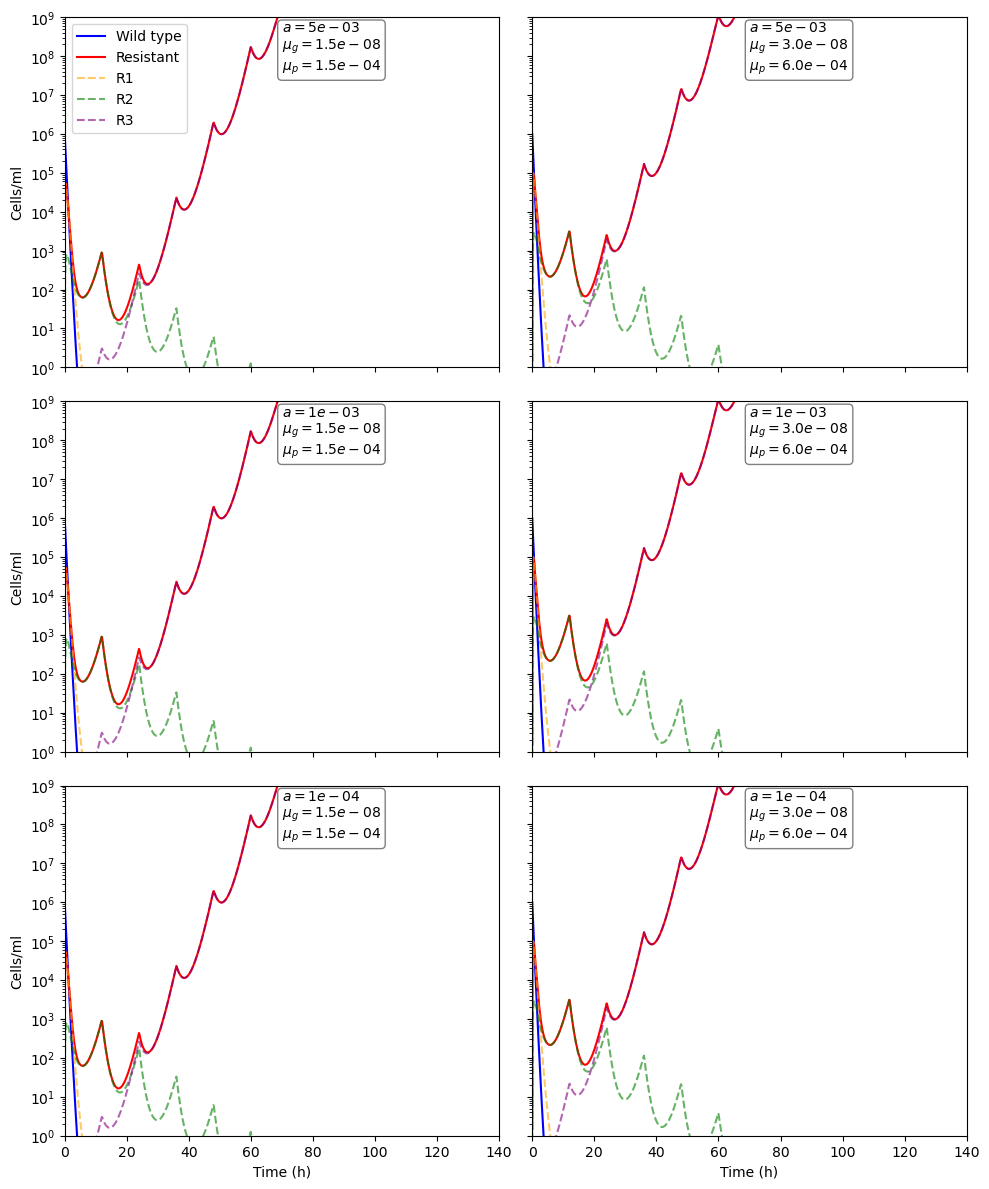

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def drug(t, decayRate, doseInterval, aPeak):
    dose_times = np.arange(0, t + 1, doseInterval)
    return np.sum([aPeak * np.exp(-decayRate * (t - d)) for d in dose_times if d <= t])

def growthRate(a, mic, gMax, gMin, kappa):
    ratio = a / mic
    return gMax - (gMax - gMin) * (ratio**kappa / (ratio**kappa + 1))

def mutationRate(g, m, tau, h):
    # safe_exp = np.exp(-h * g) if g < 100 else 0  # prevent overflow
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, p['mic'][0], p['gMax'], p['gMin'], p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, p['mic'][1], p['gMaxR'], p['gMin'], p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, p['mic'][2], p['gMaxR'], p['gMin'], p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, p['mic'][3], p['gMaxR'], p['gMin'], p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw
    dPw = aRate * nw - b * pw - muP * pw
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2
    dE = 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

# Shared parameters
baseParams = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -6.5,
    'kappa': 1,
    'c': 1e10,
    'b': 0.1,
    'tau': 2,
    'h': 5,
    'immune': False,
    'mutation': True,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2) / 2.5
}

# Define panel parameters
aVals = [5e-3, 1e-3, 1e-4]
mutationVals = [(1.5e-8, 1.5e-4), (3e-8, 6e-4)]

# Integration
tSpan = (0, 140)
tEval = np.linspace(*tSpan, 1000)
y0 = [1e7, 0, 1, 0, 0, 0, 0, 0, 0]


fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for i, aMax in enumerate(aVals):
    for j, (muG, muP) in enumerate(mutationVals):
        p = baseParams.copy()
        p['aMax'] = aMax
        p['m'] = muG
        p['muP'] = muP
        sol = solve_ivp(system, tSpan, y0, args=(p,), t_eval=tEval, method='LSODA')
        y = np.clip(sol.y, 1e-1, None)

        wt = y[0] + y[1]
        r1 = y[2] + y[3]
        r2 = y[4] + y[5]
        r3 = y[6] + y[7]
        rs = r1 + r2 + r3

        ax = axs[i, j]
        ax.plot(sol.t, wt, label='Wild type', color='blue')
        ax.plot(sol.t, rs, label='Resistant', color='red')
        ax.plot(sol.t, r1, '--', color='orange', alpha=0.6, label='R1' if i == 0 and j == 0 else None)
        ax.plot(sol.t, r2, '--', color='green', alpha=0.6, label='R2' if i == 0 and j == 0 else None)
        ax.plot(sol.t, r3, '--', color='purple', alpha=0.6, label='R3' if i == 0 and j == 0 else None)

        ax.set_yscale('log')
        ax.set_xlim(*tSpan)
        ax.set_ylim(1, 1e9)
        if i == 2:
            ax.set_xlabel('Time (h)')
        if j == 0:
            ax.set_ylabel('Cells/ml')
        if i == 0 and j == 0:
            ax.legend()
        label = f'$a={aMax:.0e}$\n$\mu_g={muG:.1e}$\n$\mu_p={muP:.1e}$'
        ax.text(0.5, 0.85, label, transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()


In [90]:
import numpy as np
from scipy.integrate import solve_ivp

def drug(t, decayRate, doseInterval, aPeak):
    n_doses = int(t // doseInterval) + 1
    dose_times = np.arange(n_doses) * doseInterval
    active = dose_times[t >= dose_times]
    return np.sum(aPeak * np.exp(-decayRate * (t - active))) if active.size > 0 else 0

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    return m * max(g, 0) + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax, gMin, gMaxR = p['gMax'], p['gMin'], p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h'])

    if int(t) % 5 == 0:
        print(f't={t:.1f} h | a(t)={a:.2f}, gWt={gWt:.4f}, muW={muW:.2e}')

    # All other derivatives same as before...
    dNw = gWt * nw - aRate * nw + b * pw - muW * nw
    dPw = aRate * nw - b * pw - p['muP'] * pw
    dNr1 = 0
    dPr1 = 0
    dNr2 = 0
    dPr2 = 0
    dNr3 = 0
    dPr3 = 0
    dE = 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

params = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': 1e-4,
    'b': 0.1,
    'm': 1.5e-8,
    'tau': 2,
    'h': 5,
    'muP': 1.5e-4,
    'immune': False,
    'mutation': True,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2)/2.5
}

y0 = [1e6, 0, 0, 0, 0, 0, 0, 0, 0]
tEval = np.linspace(0, 140, 1000)
solve_ivp(system, (0, 140), y0, args=(params,), t_eval=tEval, method='LSODA')


t=0.0 h | a(t)=25.00, gWt=-6.2103, muW=9.18e+05
t=0.0 h | a(t)=25.00, gWt=-6.2103, muW=9.18e+05
t=0.0 h | a(t)=25.00, gWt=-6.2103, muW=9.18e+05
t=0.0 h | a(t)=25.00, gWt=-6.2104, muW=9.18e+05
t=0.0 h | a(t)=25.00, gWt=-6.2104, muW=9.18e+05
t=0.0 h | a(t)=25.00, gWt=-6.2106, muW=9.19e+05
t=0.0 h | a(t)=25.00, gWt=-6.2106, muW=9.19e+05
t=0.0 h | a(t)=25.00, gWt=-6.2107, muW=9.19e+05
t=0.0 h | a(t)=25.00, gWt=-6.2107, muW=9.19e+05
t=0.0 h | a(t)=25.00, gWt=-6.2108, muW=9.20e+05
t=0.0 h | a(t)=25.00, gWt=-6.2108, muW=9.20e+05
t=0.0 h | a(t)=25.00, gWt=-6.2110, muW=9.21e+05
t=0.0 h | a(t)=25.00, gWt=-6.2110, muW=9.21e+05
t=0.0 h | a(t)=25.00, gWt=-6.2111, muW=9.21e+05
t=0.0 h | a(t)=25.00, gWt=-6.2111, muW=9.21e+05
t=0.0 h | a(t)=25.00, gWt=-6.2112, muW=9.22e+05
t=0.0 h | a(t)=25.00, gWt=-6.2112, muW=9.22e+05
t=0.0 h | a(t)=25.00, gWt=-6.2113, muW=9.22e+05
t=0.0 h | a(t)=25.00, gWt=-6.2113, muW=9.22e+05
t=0.0 h | a(t)=25.00, gWt=-6.2114, muW=9.22e+05
t=0.0 h | a(t)=25.00, gWt=-6.2114, muW=9

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.401e-01 ...  1.399e+02  1.400e+02]
        y: [[ 1.000e+06  1.227e-15 ...  1.856e-14  1.814e-14]
            [ 0.000e+00  1.070e-08 ...  4.016e-11  3.960e-11]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 272
     njev: 9
      nlu: 9

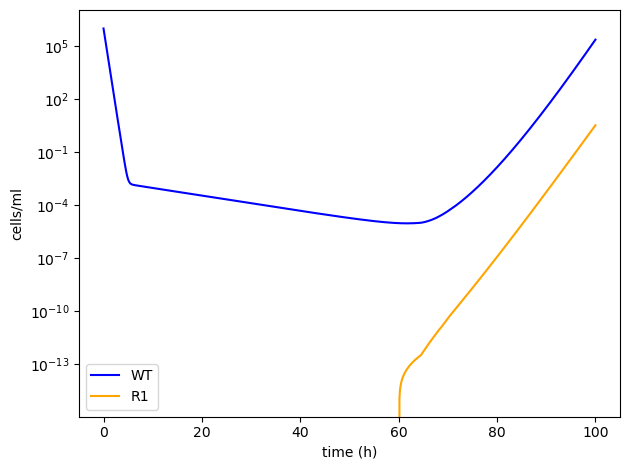

In [89]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * t)  # Only a single initial bolus

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a ** kappa / (a ** kappa + mic ** kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g) if g > 0 else 0

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax, gMin, gMaxR = p['gMax'], p['gMin'], p['gMaxR']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']
    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    muW = mutationRate(gWt, p['m'], p['tau'], p['h'])

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw
    dPw = aRate * nw - b * pw - p['muP'] * pw
    dNr1 = gR1 * nr1 + muW * nw
    dPr1 = 0
    dNr2 = 0
    dPr2 = 0
    dNr3 = 0
    dPr3 = 0
    dE = 0
    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

params = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMaxR': 0.9,
    'gMin': -4.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': 1e-4,
    'b': 0.1,
    'm': 1.5e-8,
    'tau': 2,
    'h': 5,
    'muP': 1.5e-4,
    'immune': False,
    'mutation': True,
    'aPeak': 15,
    'doseInterval': 12,
    'decayRate': np.log(2)/10  # much slower decay
}

y0 = [1e6, 0, 0, 0, 0, 0, 0, 0, 0]
tEval = np.linspace(0, 100, 1000)
sol = solve_ivp(system, (0, 100), y0, args=(params,), t_eval=tEval, method='LSODA')

plt.plot(sol.t, sol.y[0] + sol.y[1], label='WT', color='blue')
plt.plot(sol.t, sol.y[2] + sol.y[3], label='R1', color='orange')
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('cells/ml')
plt.legend()
plt.tight_layout()
plt.show()


variable Ax dosing strategy

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': 0.0001,
    'b': 0.1,
    'm': 1.5e-8,
    'tau': 2,
    'h': 5,
    'muP': 1.5e-4,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2) / 2.5
}

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def drugProfile(t, doseTimes, doseAmts, decayRate):
    total = 0
    for tDose, dose in zip(doseTimes, doseAmts):
        if t >= tDose:
            total += dose * np.exp(-decayRate * (t - tDose))
    return total

params['doseTimes'] = [0, 12, 24, 36, 48]  # hours
params['doseAmts'] = [25, 25, 25, 25, 25]

def drugContinuous(t, doseTimes, doseAmts, decayRate, infusion=False, infusionStart=0, infusionEnd=0, infusionRate=0):
    total = 0
    # bolus doses
    for tDose, dose in zip(doseTimes, doseAmts):
        if t >= tDose:
            total += dose * np.exp(-decayRate * (t - tDose))
    # continuous infusion
    if infusion and infusionStart <= t <= infusionEnd:
        # each hour adds drug, decays since infusionStart
        infusionTime = t - infusionStart
        total += infusionRate * infusionTime * np.exp(-decayRate * infusionTime)
    return total

params.update({
    'infusion': True,
    'infusionStart': 0,
    'infusionEnd': 48,  # hours
    'infusionRate': 5   # units of drug per hour
})

def drugProfile(t, doseTimes, doseAmts, decayRate, infusion=False, infusionStart=0, infusionEnd=0, infusionRate=0):
    total = 0
    # bolus doses
    for tDose, dose in zip(doseTimes, doseAmts):
        if t >= tDose:
            total += dose * np.exp(-decayRate * (t - tDose))
    # continuous infusion
    if infusion and infusionStart <= t <= infusionEnd:
        # each hour adds drug, decays since infusionStart
        infusionTime = t - infusionStart
        total += infusionRate * infusionTime * np.exp(-decayRate * infusionTime)
    return total


def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    a = drugProfile(t, p['doseTimes'], p['doseAmts'], p['decayRate'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
